# Chargement des données historiques de crimes NYPD avec PySpark


In [2]:
from pyspark.sql import SparkSession

# Création de la SparkSession
spark = SparkSession.builder \
    .appName("NYC Crime Hotspots Analysis") \
    .getOrCreate()

# Lecture du fichier CSV en entier
df = spark.read.csv(
    "C:\\Users\\Nassim\\Downloads\\NYPD_Complaint_Data_Historic.csv",
    header=True,
    inferSchema=True
)

# Affichage du schéma et des premières lignes pour vérification
df.printSchema()
df.show(5, truncate=False)


root
 |-- CMPLNT_NUM: string (nullable = true)
 |-- CMPLNT_FR_DT: string (nullable = true)
 |-- CMPLNT_FR_TM: string (nullable = true)
 |-- CMPLNT_TO_DT: string (nullable = true)
 |-- CMPLNT_TO_TM: string (nullable = true)
 |-- ADDR_PCT_CD: integer (nullable = true)
 |-- RPT_DT: string (nullable = true)
 |-- KY_CD: integer (nullable = true)
 |-- OFNS_DESC: string (nullable = true)
 |-- PD_CD: integer (nullable = true)
 |-- PD_DESC: string (nullable = true)
 |-- CRM_ATPT_CPTD_CD: string (nullable = true)
 |-- LAW_CAT_CD: string (nullable = true)
 |-- BORO_NM: string (nullable = true)
 |-- LOC_OF_OCCUR_DESC: string (nullable = true)
 |-- PREM_TYP_DESC: string (nullable = true)
 |-- JURIS_DESC: string (nullable = true)
 |-- JURISDICTION_CODE: integer (nullable = true)
 |-- PARKS_NM: string (nullable = true)
 |-- HADEVELOPT: string (nullable = true)
 |-- HOUSING_PSA: string (nullable = true)
 |-- X_COORD_CD: integer (nullable = true)
 |-- Y_COORD_CD: integer (nullable = true)
 |-- SUSP_AGE

## Prétraitement : conversion des dates et heures en timestamp


In [3]:
from pyspark.sql.functions import to_timestamp, concat_ws, col

# Création d'une colonne datetime à partir des colonnes CMPLNT_FR_DT et CMPLNT_FR_TM
df = df.withColumn(
    "occur_datetime",
    to_timestamp(
        concat_ws(" ", col("CMPLNT_FR_DT"), col("CMPLNT_FR_TM")),
        "MM/dd/yyyy HH:mm:ss"
    )
)

# Vérification du schéma et aperçu des nouvelles colonnes
df.printSchema()
df.select("CMPLNT_FR_DT", "CMPLNT_FR_TM", "occur_datetime").show(5, truncate=False)


root
 |-- CMPLNT_NUM: string (nullable = true)
 |-- CMPLNT_FR_DT: string (nullable = true)
 |-- CMPLNT_FR_TM: string (nullable = true)
 |-- CMPLNT_TO_DT: string (nullable = true)
 |-- CMPLNT_TO_TM: string (nullable = true)
 |-- ADDR_PCT_CD: integer (nullable = true)
 |-- RPT_DT: string (nullable = true)
 |-- KY_CD: integer (nullable = true)
 |-- OFNS_DESC: string (nullable = true)
 |-- PD_CD: integer (nullable = true)
 |-- PD_DESC: string (nullable = true)
 |-- CRM_ATPT_CPTD_CD: string (nullable = true)
 |-- LAW_CAT_CD: string (nullable = true)
 |-- BORO_NM: string (nullable = true)
 |-- LOC_OF_OCCUR_DESC: string (nullable = true)
 |-- PREM_TYP_DESC: string (nullable = true)
 |-- JURIS_DESC: string (nullable = true)
 |-- JURISDICTION_CODE: integer (nullable = true)
 |-- PARKS_NM: string (nullable = true)
 |-- HADEVELOPT: string (nullable = true)
 |-- HOUSING_PSA: string (nullable = true)
 |-- X_COORD_CD: integer (nullable = true)
 |-- Y_COORD_CD: integer (nullable = true)
 |-- SUSP_AGE

## Nettoyage des données : suppression des enregistrements sans date ou coordonnées


In [4]:
from pyspark.sql.functions import col

# Filtrer les lignes où la date/heure et les coordonnées sont présentes
df_clean = df.filter(
    col("occur_datetime").isNotNull() &
    col("Latitude").isNotNull() &
    col("Longitude").isNotNull()
)

# Nombre de lignes avant et après nettoyage
total_count = df.count()
clean_count = df_clean.count()

print(f"Total enregistrements : {total_count}")
print(f"Enregistrements après nettoyage : {clean_count}")


Total enregistrements : 9491946
Enregistrements après nettoyage : 9490765


### Conversion de occur_datetime en Timestamp et extraction des composantes temporelles


In [5]:
from pyspark.sql.functions import to_timestamp, year, month, dayofmonth, hour

# Conversion en Timestamp et extraction des colonnes year, month, day, hour
df_time = df_clean \
    .withColumn("occur_ts", to_timestamp(col("occur_datetime"))) \
    .withColumn("year", year(col("occur_ts"))) \
    .withColumn("month", month(col("occur_ts"))) \
    .withColumn("day", dayofmonth(col("occur_ts"))) \
    .withColumn("hour", hour(col("occur_ts")))

# Aperçu des 5 premières lignes pour vérification
df_time.select("occur_datetime", "occur_ts", "year", "month", "day", "hour").show(5, truncate=False)


+-------------------+-------------------+----+-----+---+----+
|occur_datetime     |occur_ts           |year|month|day|hour|
+-------------------+-------------------+----+-----+---+----+
|2008-02-20 07:00:00|2008-02-20 07:00:00|2008|2    |20 |7   |
|2008-08-21 22:00:00|2008-08-21 22:00:00|2008|8    |21 |22  |
|2008-04-03 03:35:00|2008-04-03 03:35:00|2008|4    |3  |3   |
|2008-08-19 09:00:00|2008-08-19 09:00:00|2008|8    |19 |9   |
|2008-03-10 22:00:00|2008-03-10 22:00:00|2008|3    |10 |22  |
+-------------------+-------------------+----+-----+---+----+
only showing top 5 rows



### Répartition annuelle des crimes


In [6]:
# Compter le nombre d'infractions par année et ordonner par année croissante
df_year = df_time.groupBy("year") \
                 .count() \
                 .orderBy("year")

df_year.show()


+----+-----+
|year|count|
+----+-----+
|1010|    6|
|1011|    3|
|1012|    6|
|1013|    1|
|1014|    5|
|1015|    9|
|1016|   18|
|1017|   24|
|1018|   27|
|1019|   13|
|1020|    2|
|1021|    7|
|1022|   12|
|1023|   23|
|1024|   19|
|1025|    1|
|1026|    5|
|1027|    3|
|1028|   10|
|1029|    4|
+----+-----+
only showing top 20 rows



In [7]:
from pyspark.sql.functions import min, max

# Calcul de l'année minimale et maximale
df_time.agg(
    min(col("year")).alias("min_year"),
    max(col("year")).alias("max_year")
).show()


+--------+--------+
|min_year|max_year|
+--------+--------+
|    1010|    2024|
+--------+--------+



### Filtrage des enregistrements post-2000


In [8]:
from pyspark.sql.functions import col

# Ne conserver que les enregistrements dont l'année est ≥ 2000
df_filtered = df_time.filter(col("year") >= 2000)

# Vérification : nombre d'enregistrements avant/après filtrage
total_before = df_time.count()
total_after = df_filtered.count()

print(f"Enregistrements avant filtrage : {total_before}")
print(f"Enregistrements après filtrage  : {total_after}")


Enregistrements avant filtrage : 9490765
Enregistrements après filtrage  : 9488186


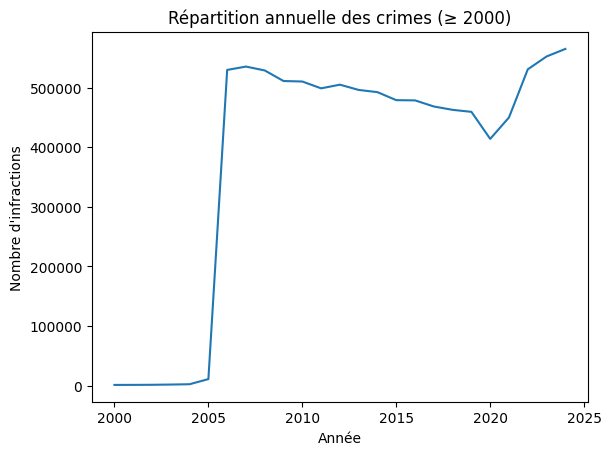

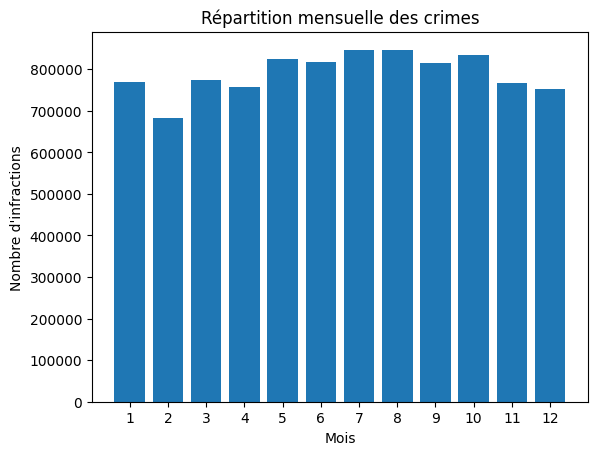

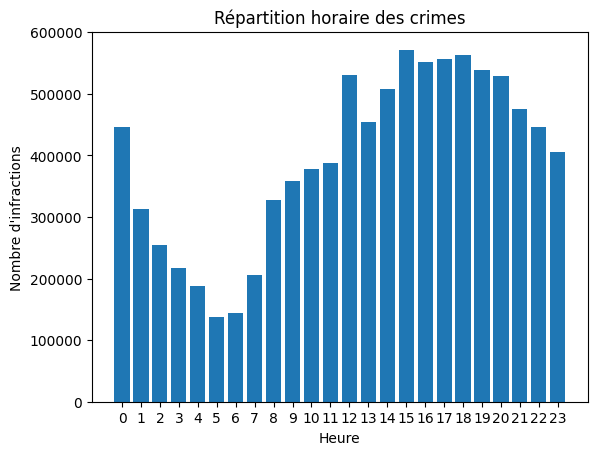

In [9]:
from pyspark.sql.functions import desc
import matplotlib.pyplot as plt

# Calcul des répartitions
df_year_filtered = df_filtered.groupBy("year").count().orderBy("year")
df_month = df_filtered.groupBy("month").count().orderBy("month")
df_hour = df_filtered.groupBy("hour").count().orderBy("hour")

# Conversion en pandas pour le tracé
df_year_pd = df_year_filtered.toPandas()
df_month_pd = df_month.toPandas()
df_hour_pd = df_hour.toPandas()

# ----- Visualisation annuelle -----
plt.figure()
plt.plot(df_year_pd['year'], df_year_pd['count'])
plt.xlabel('Année')
plt.ylabel("Nombre d'infractions")
plt.title('Répartition annuelle des crimes (≥ 2000)')
plt.show()

# ----- Visualisation mensuelle -----
plt.figure()
plt.bar(df_month_pd['month'], df_month_pd['count'])
plt.xlabel('Mois')
plt.ylabel("Nombre d'infractions")
plt.title('Répartition mensuelle des crimes')
plt.xticks(range(1, 13))
plt.show()

# ----- Visualisation horaire -----
plt.figure()
plt.bar(df_hour_pd['hour'], df_hour_pd['count'])
plt.xlabel('Heure')
plt.ylabel("Nombre d'infractions")
plt.title('Répartition horaire des crimes')
plt.xticks(range(0, 24))
plt.show()


### Filtrage des enregistrements pour ne conserver que les années ≥ 2006


In [10]:
from pyspark.sql.functions import col

# Ne garder que les crimes à partir de 2006 (exclure 2005)
df_no2005 = df_filtered.filter(col("year") >= 2006)

# Vérification : nombre d'enregistrements avant/après ce nouveau filtrage
before_no2005 = df_filtered.count()
after_no2005 = df_no2005.count()
print(f"Enregistrements avant filtrage ≥2006 : {before_no2005}")
print(f"Enregistrements après filtrage ≥2006  : {after_no2005}")

# Afficher la répartition annuelle mise à jour (2006–2024)
df_no2005.groupBy("year").count().orderBy("year").show()


Enregistrements avant filtrage ≥2006 : 9488186
Enregistrements après filtrage ≥2006  : 9469842
+----+------+
|year| count|
+----+------+
|2006|529853|
|2007|535469|
|2008|528968|
|2009|511223|
|2010|510397|
|2011|498943|
|2012|505092|
|2013|496255|
|2014|492532|
|2015|479099|
|2016|478711|
|2017|468470|
|2018|462836|
|2019|459481|
|2020|414073|
|2021|450073|
|2022|530831|
|2023|552431|
|2024|565105|
+----+------+



### Répartition des crimes par borough (2006–2024) et visualisation


+-------------+-------+
|      BORO_NM|  count|
+-------------+-------+
|     BROOKLYN|2770688|
|    MANHATTAN|2283236|
|        BRONX|2049883|
|       QUEENS|1924101|
|STATEN ISLAND| 433228|
|       (null)|   8706|
+-------------+-------+



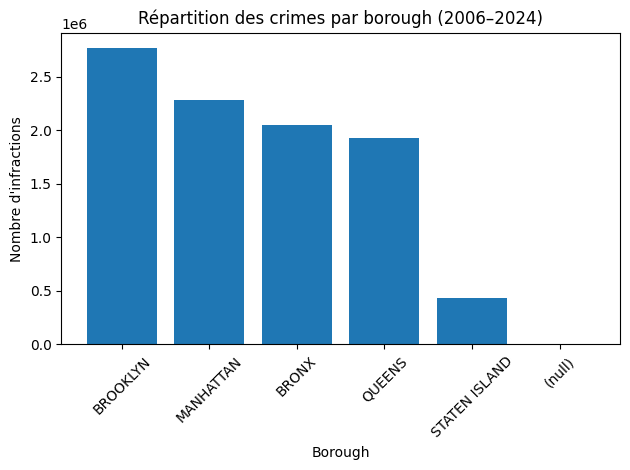

In [11]:
from pyspark.sql.functions import desc
import matplotlib.pyplot as plt

# Calcul du nombre d’infractions par borough (colonne BORO_NM)
df_borough = df_no2005.groupBy("BORO_NM") \
                      .count() \
                      .orderBy(desc("count"))

# Affichage des chiffres bruts
df_borough.show()

# Passage en pandas pour le tracé
df_borough_pd = df_borough.toPandas()

# Visualisation
plt.figure()
plt.bar(df_borough_pd['BORO_NM'], df_borough_pd['count'])
plt.xlabel('Borough')
plt.ylabel("Nombre d'infractions")
plt.title('Répartition des crimes par borough (2006–2024)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Suppression des enregistrements où `BORO_NM` est null


In [12]:
from pyspark.sql.functions import col

# Comptage des enregistrements à BORO_NM null
null_borough_count = df_no2005.filter(col("BORO_NM").isNull()).count()
print(f"Nombre d'enregistrements sans borough : {null_borough_count}")

# Création d'un DataFrame final sans nulls sur BORO_NM
df_final = df_no2005.filter(col("BORO_NM").isNotNull())

# Vérification
final_count = df_final.count()
print(f"Total après suppression des nulls sur BORO_NM : {final_count}")


Nombre d'enregistrements sans borough : 0
Total après suppression des nulls sur BORO_NM : 9469842


### Distribution des types d'infractions (Top 10) par borough


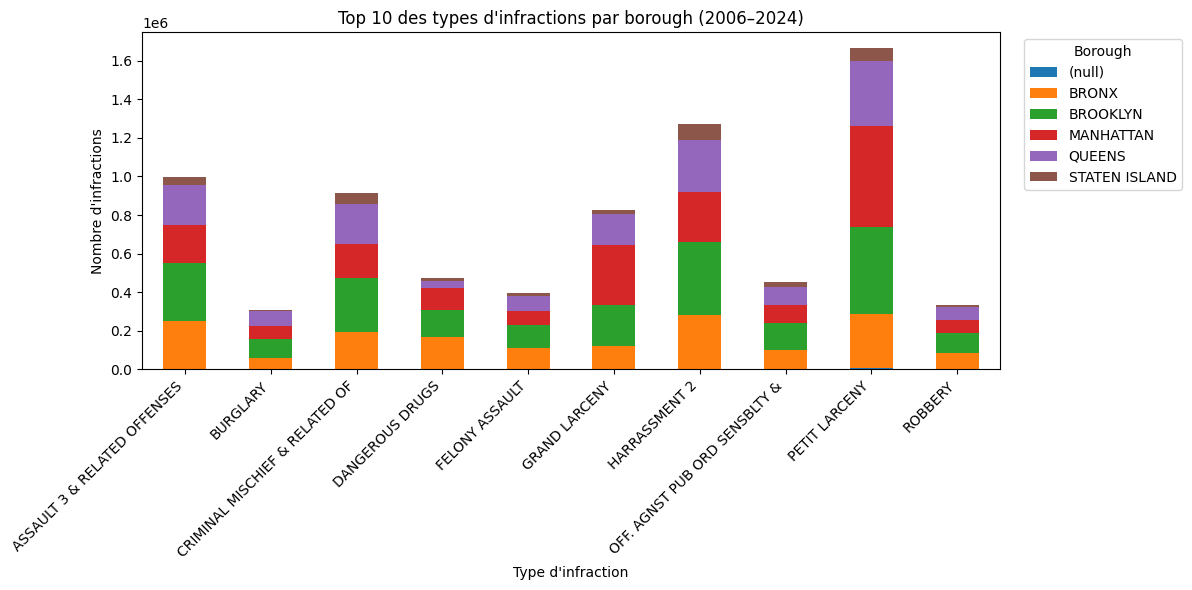

In [13]:
from pyspark.sql.functions import desc, col
import matplotlib.pyplot as plt

# 1. Calculer le total par type d'infraction
df_offense_tot = df_final.groupBy("OFNS_DESC") \
                         .count() \
                         .withColumnRenamed("count", "total") 

# 2. Sélectionner les 10 types les plus fréquents
top10 = [row["OFNS_DESC"] for row in df_offense_tot.orderBy(desc("total")).limit(10).collect()]

# 3. Compter ces top 10 par borough
df_offense_boro = df_final.filter(col("OFNS_DESC").isin(top10)) \
                          .groupBy("OFNS_DESC", "BORO_NM") \
                          .count()

# 4. Passage en pandas et pivot pour tracer
pdf = df_offense_boro.toPandas()
pdf_pivot = pdf.pivot(index="OFNS_DESC", columns="BORO_NM", values="count").fillna(0)

# 5. Tracé en barres empilées
pdf_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)
plt.xlabel("Type d'infraction")
plt.ylabel("Nombre d'infractions")
plt.title("Top 10 des types d'infractions par borough (2006–2024)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Borough", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Préparation des séries mensuelles et split train/test pour la prévision


In [14]:
from pyspark.sql.functions import date_format, col
import pandas as pd

# 1. Agréger le nombre de crimes par mois ("YYYY-MM")
df_monthly = df_final.withColumn(
    "year_month",
    date_format(col("occur_ts"), "yyyy-MM")
).groupBy("year_month") \
 .count() \
 .orderBy("year_month")

# 2. Convertir en pandas et formater pour Prophet/ARIMA
pdf_monthly = df_monthly.toPandas()
pdf_monthly["ds"] = pd.to_datetime(pdf_monthly["year_month"] + "-01")
pdf_monthly = pdf_monthly.rename(columns={"count": "y"}).sort_values("ds")
pdf_monthly = pdf_monthly.set_index("ds")[["y"]]

# 3. Définir l’horizon de test : 12 derniers mois disponibles
horizon = 12
train = pdf_monthly.iloc[:-horizon].copy()
test  = pdf_monthly.iloc[-horizon:].copy()

print(f"Train : {train.index[0].date()} → {train.index[-1].date()} ({len(train)} mois)")
print(f"Test  : {test.index[0].date()} → {test.index[-1].date()} ({len(test)} mois)")


Train : 2006-01-01 → 2023-12-01 (216 mois)
Test  : 2024-01-01 → 2024-12-01 (12 mois)


### Entraînement du modèle Prophet et évaluation sur la période test


Importing plotly failed. Interactive plots will not work.
13:03:54 - cmdstanpy - INFO - Chain [1] start processing
13:03:54 - cmdstanpy - INFO - Chain [1] done processing


MAE test Prophet   : 1280.6
RMSE test Prophet  : 1973.7


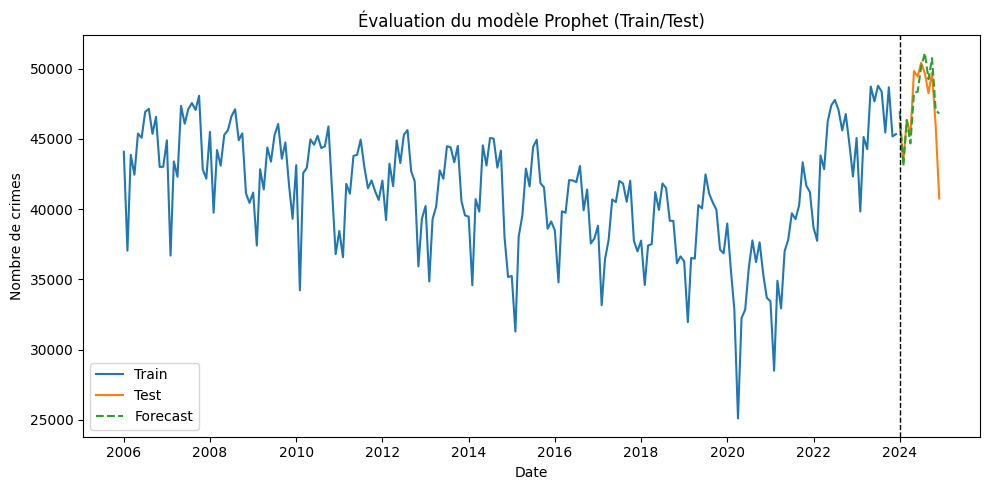

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math
import matplotlib.pyplot as plt
from prophet import Prophet

# 1. Préparer le DataFrame pour Prophet à partir de train
df_train = train.reset_index().rename(columns={'ds':'ds','y':'y'})

# 2. Ajuster Prophet
m = Prophet(yearly_seasonality=12, weekly_seasonality=False, daily_seasonality=False)
m.add_country_holidays(country_name='US')
m.fit(df_train)

# 3. Générer les prédictions pour l'horizon de test
future = m.make_future_dataframe(periods=horizon, freq='MS')
fc = m.predict(future).set_index('ds')['yhat'].loc[test.index]

# 4. Calculer MAE et RMSE manuellement
mae = mean_absolute_error(test['y'], fc)
mse = mean_squared_error(test['y'], fc)  # retourne le MSE
rmse = math.sqrt(mse)

print(f"MAE test Prophet   : {mae:.1f}")
print(f"RMSE test Prophet  : {rmse:.1f}")

# 5. Tracer Train / Test / Prévision
plt.figure(figsize=(10, 5))
plt.plot(train.index, train['y'], label='Train')
plt.plot(test.index,  test['y'],  label='Test')
plt.plot(test.index,  fc,         '--', label='Forecast')
plt.axvline(test.index[0], color='k', linestyle='--', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Nombre de crimes')
plt.title('Évaluation du modèle Prophet (Train/Test)')
plt.legend()
plt.tight_layout()
plt.show()


### 1. Évaluation de SARIMA sur la période test


C:\Users\Nassim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Nassim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA MAE  test : 1461.8
SARIMA RMSE test : 2343.9


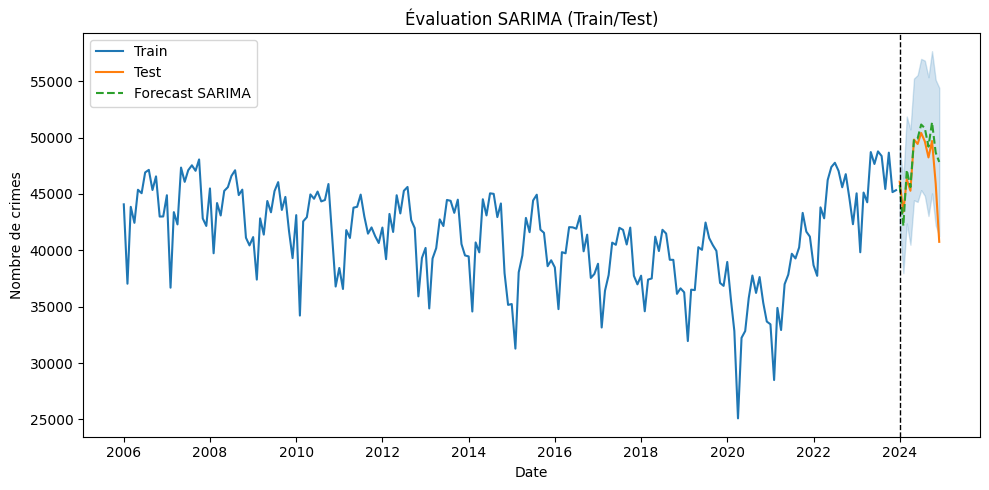

In [16]:
import pandas as pd
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

# On repart du même train/test (déjà créés)
# train.index, train['y'] et test.index, test['y']

# 1. Ajuster SARIMA(1,1,1)(1,1,1,12) sur le train
model = SARIMAX(train['y'],
                order=(1,1,1),
                seasonal_order=(1,1,1,12),
                enforce_stationarity=False,
                enforce_invertibility=False)
res = model.fit(disp=False)

# 2. Prédire la période test
pred_test = res.get_forecast(steps=len(test))
fc_sarima = pred_test.predicted_mean
ci_sarima = pred_test.conf_int()

# 3. Calculer MAE/RMSE
mae_s = mean_absolute_error(test['y'], fc_sarima)
mse_s = mean_squared_error(test['y'], fc_sarima)
rmse_s = math.sqrt(mse_s)

print(f"SARIMA MAE  test : {mae_s:.1f}")
print(f"SARIMA RMSE test : {rmse_s:.1f}")

# 4. Tracé comparatif
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(train.index, train['y'], label='Train')
plt.plot(test.index,  test['y'],  label='Test')
plt.plot(test.index,  fc_sarima, '--', label='Forecast SARIMA')
plt.fill_between(ci_sarima.index, ci_sarima.iloc[:,0], ci_sarima.iloc[:,1],
                 color='C0', alpha=0.2)
plt.axvline(test.index[0], color='k', linestyle='--', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Nombre de crimes')
plt.title('Évaluation SARIMA (Train/Test)')
plt.legend()
plt.tight_layout()
plt.show()


### 3. Choix du modèle (Prophet) et prévision finale sur toute la série


13:20:01 - cmdstanpy - INFO - Chain [1] start processing
13:20:01 - cmdstanpy - INFO - Chain [1] done processing


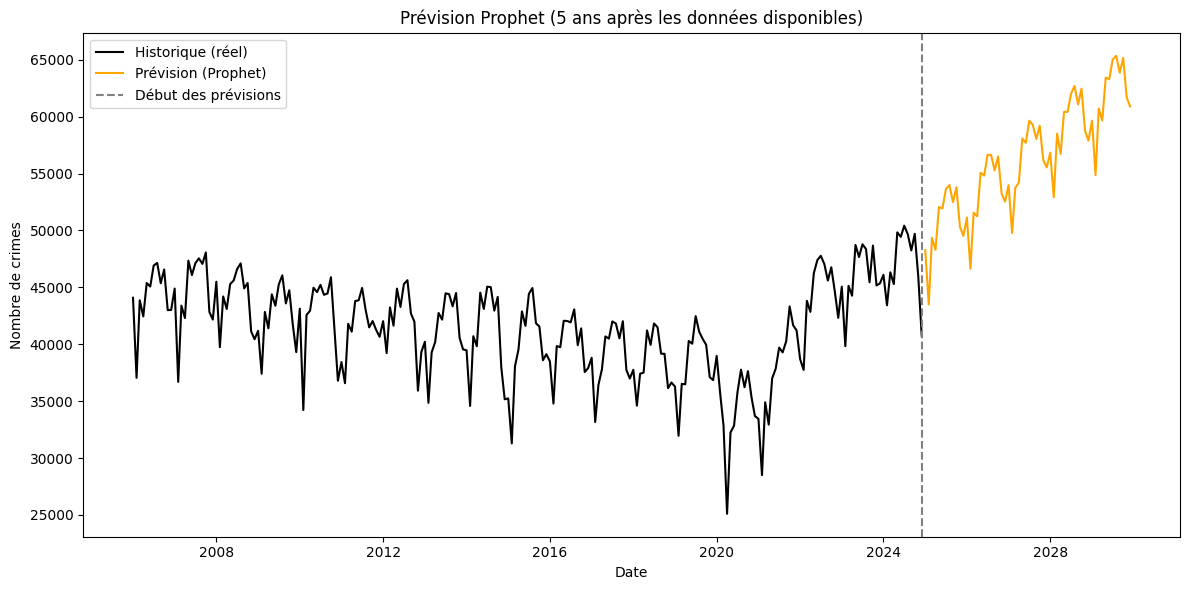

In [22]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# 1. Fusion train + test pour Prophet
full_df = pd.concat([train, test])
full_df = full_df.reset_index().rename(columns={"index": "ds"})

# 2. Entraînement Prophet
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(full_df)

# 3. Générer uniquement les 5 ans futurs (et pas toute l’histoire)
future = model.make_future_dataframe(periods=5 * 12, freq='MS')  # 5 ans
forecast = model.predict(future)

# 4. Filtrer uniquement les dates après la fin des vraies données
start_forecast_date = full_df['ds'].max()
forecast_future_only = forecast[forecast['ds'] > start_forecast_date]

# 5. Affichage propre
fig, ax = plt.subplots(figsize=(12, 6))

# Historique réel
ax.plot(full_df['ds'], full_df['y'], label='Historique (réel)', color='black')

# Prévision uniquement après les vraies données
ax.plot(forecast_future_only['ds'], forecast_future_only['yhat'], label='Prévision (Prophet)', color='orange')

# Ligne de séparation
ax.axvline(start_forecast_date, color='grey', linestyle='--', label='Début des prévisions')

# Mise en forme
ax.set_xlabel("Date")
ax.set_ylabel("Nombre de crimes")
ax.set_title("Prévision Prophet (5 ans après les données disponibles)")
ax.legend()
plt.tight_layout()
plt.show()
